# Regime-Gated Equity Curve

Point-in-time macro regimes (30d BTCDOM SMA + 52w rolling Funding %ile).
Execution gated to **Q2 Weak Funding + Rising BTCDOM** (Regime Filter).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")
try:
    BASE_DIR = Path(__file__).resolve().parents[1]
except NameError:
    BASE_DIR = Path.cwd().resolve().parents[0]

MSM_TIMESERIES_PATH = BASE_DIR / "reports" / "msm_funding_v0" / "msm_v0_full_2023_2026" / "msm_timeseries.csv"
RECON_BTCDOM_PATH = BASE_DIR / "data" / "curated" / "data_lake" / "btcdom_reconstructed.csv"
BINANCE_BTCDOM_PATH = BASE_DIR / "data" / "curated" / "data_lake" / "binance_btcdom.csv"

In [ ]:
# Load MSM and reconstructed BTCDOM; recreate point-in-time regimes
msm = pd.read_csv(MSM_TIMESERIES_PATH, parse_dates=["decision_date", "next_date"])
msm = msm[["decision_date", "next_date", "F_tk", "y"]].copy().sort_values("decision_date").reset_index(drop=True)

recon_btcd = pd.read_csv(RECON_BTCDOM_PATH, parse_dates=["date"]).sort_values("date")
recon_levels = recon_btcd[["date", "reconstructed_index_value"]].rename(columns={"reconstructed_index_value": "btcd_index"})

msm = msm.merge(
    recon_levels.rename(columns={"date": "decision_date", "btcd_index": "btcd_index_decision"}),
    on="decision_date", how="left",
)
msm = msm.merge(
    recon_levels.rename(columns={"date": "next_date", "btcd_index": "btcd_index_next"}),
    on="next_date", how="left",
)
msm["ret_btcdom_recon"] = msm["btcd_index_next"] / msm["btcd_index_decision"] - 1.0

# Binance BTCDOM: merge daily levels onto decision_date and next_date
binance_df = pd.read_csv(BINANCE_BTCDOM_PATH, parse_dates=["timestamp"])
_ts = binance_df["timestamp"]
if getattr(_ts.dt, "tz", None) is not None:
    binance_df["timestamp"] = _ts.dt.tz_convert(None)
else:
    binance_df["timestamp"] = _ts
binance_df["date"] = binance_df["timestamp"].dt.normalize()
binance_levels = binance_df[["date", "close"]].rename(columns={"close": "binance_index"})
msm = msm.merge(
    binance_levels.rename(columns={"date": "decision_date", "binance_index": "binance_decision"}),
    on="decision_date", how="left",
)
msm = msm.merge(
    binance_levels.rename(columns={"date": "next_date", "binance_index": "binance_next"}),
    on="next_date", how="left",
)
msm["ret_btcdom_binance"] = msm["binance_next"] / msm["binance_decision"] - 1.0

recon_btcd["sma_30"] = recon_btcd["reconstructed_index_value"].rolling(window=30, min_periods=30).mean()
sma_df = recon_btcd[["date", "sma_30"]].rename(columns={"date": "decision_date", "sma_30": "sma_30_decision"})
msm = msm.merge(sma_df, on="decision_date", how="left")

msm = msm.sort_values("decision_date").reset_index(drop=True)
msm["funding_pct_rank"] = msm["F_tk"].rolling(window=52, min_periods=26).apply(
    lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False
)
msm["funding_regime"] = pd.cut(
    msm["funding_pct_rank"],
    bins=[0.0, 0.25, 0.50, 0.75, 1.0],
    labels=["Q1: Negative/Low", "Q2: Weak", "Q3: Neutral", "Q4: High"],
    include_lowest=True,
)
msm["BTCDOM_Trend"] = np.where(msm["btcd_index_decision"] > msm["sma_30_decision"], "Rising", "Falling")

# Align all series: drop rows where benchmark returns are NaN
df = msm.dropna(subset=["y", "funding_regime", "BTCDOM_Trend", "ret_btcdom_recon", "ret_btcdom_binance"]).copy()
is_disbelief = (df["funding_regime"] == "Q2: Weak") & (df["BTCDOM_Trend"] == "Rising")
df["is_mrf_active"] = is_disbelief
df["y_filtered"] = np.where(is_disbelief, df["y"], 0.0)
df["recon_filtered"] = np.where(is_disbelief, df["ret_btcdom_recon"], 0.0)
df["binance_filtered"] = np.where(is_disbelief, df["ret_btcdom_binance"], 0.0)
# Cumulative compounded returns (institutional: 0 = 0%, 1 = 100%)
df["cum_raw_ls"] = (1 + df["y"]).cumprod() - 1
df["cum_filtered_ls"] = (1 + df["y_filtered"]).cumprod() - 1
df["cum_recon_btcdom"] = (1 + df["ret_btcdom_recon"]).cumprod() - 1
df["cum_binance_btcdom"] = (1 + df["ret_btcdom_binance"]).cumprod() - 1
df["cum_recon_filtered"] = (1 + df["recon_filtered"]).cumprod() - 1
df["cum_binance_filtered"] = (1 + df["binance_filtered"]).cumprod() - 1
df.head(10)

,decision_date,next_date,F_tk,y,btcd_index_decision,btcd_index_next,ret_btcdom_recon,binance_decision,binance_next,ret_btcdom_binance,...,funding_pct_rank,funding_regime,BTCDOM_Trend,y_filtered,recon_filtered,binance_filtered,cum_raw_ls,cum_filtered_ls,cum_recon_btcdom,cum_binance_btcdom
25,2024-07-29,2024-08-05,0.004618,0.057569,2660.735888,2786.003904,0.047080,2525.981048,2741.656678,0.085383,...,0.307692,Q2: Weak,Falling,0.000000,0.000000,0.000000,0.057569,0.000000,0.047080,0.085383
26,2024-08-05,2024-08-12,0.002222,-0.013788,2786.003904,2894.410654,0.038911,2741.656678,2712.360651,-0.010686,...,0.148148,Q1: Negative/Low,Rising,0.000000,0.000000,0.000000,0.042987,0.000000,0.087823,0.073785
27,2024-08-12,2024-08-19,-0.004502,0.003920,2894.410654,2867.678660,-0.009236,2712.360651,2734.662916,0.008222,...,0.035714,Q1: Negative/Low,Rising,0.000000,0.000000,0.000000,0.047076,0.000000,0.077777,0.082614
28,2024-08-19,2024-08-26,0.001184,-0.095705,2867.678660,2891.809974,0.008415,2734.662916,2825.895101,0.033361,...,0.137931,Q1: Negative/Low,Rising,0.000000,0.000000,0.000000,-0.053134,0.000000,0.086846,0.118732
29,2024-08-26,2024-09-02,0.004727,0.046381,2891.809974,3001.757234,0.038020,2825.895101,2837.051400,0.003948,...,0.400000,Q2: Weak,Rising,0.046381,0.038020,0.003948,-0.009217,0.046381,0.128168,0.123148
30,2024-09-02,2024-09-09,-0.002083,-0.047800,3001.757234,2966.347705,-0.011796,2837.051400,2856.855115,0.006980,...,0.064516,Q1: Negative/Low,Rising,0.000000,0.000000,0.000000,-0.056577,0.046381,0.114860,0.130988
31,2024-09-09,2024-09-16,-0.000642,-0.005832,2966.347705,3088.752305,0.041264,2856.855115,2954.325028,0.034118,...,0.125000,Q1: Negative/Low,Rising,0.000000,0.000000,0.000000,-0.062079,0.046381,0.160864,0.169575
32,2024-09-16,2024-09-23,0.003167,-0.036458,3088.752305,3037.576557,-0.016568,2954.325028,2866.153406,-0.029845,...,0.303030,Q2: Weak,Rising,-0.036458,-0.016568,-0.029845,-0.096273,0.008232,0.141630,0.134669
33,2024-09-23,2024-09-30,0.004706,-0.060779,3037.576557,2974.011012,-0.020926,2866.153406,2882.700910,0.005773,...,0.441176,Q2: Weak,Rising,-0.060779,-0.020926,0.005773,-0.151201,-0.053048,0.117740,0.141220
34,2024-09-30,2024-10-07,0.008265,0.022066,2974.011012,2997.803362,0.008000,2882.700910,3014.873991,0.045850,...,0.685714,Q3: Neutral,Falling,0.000000,0.000000,0.000000,-0.132472,-0.053048,0.126682,0.193546


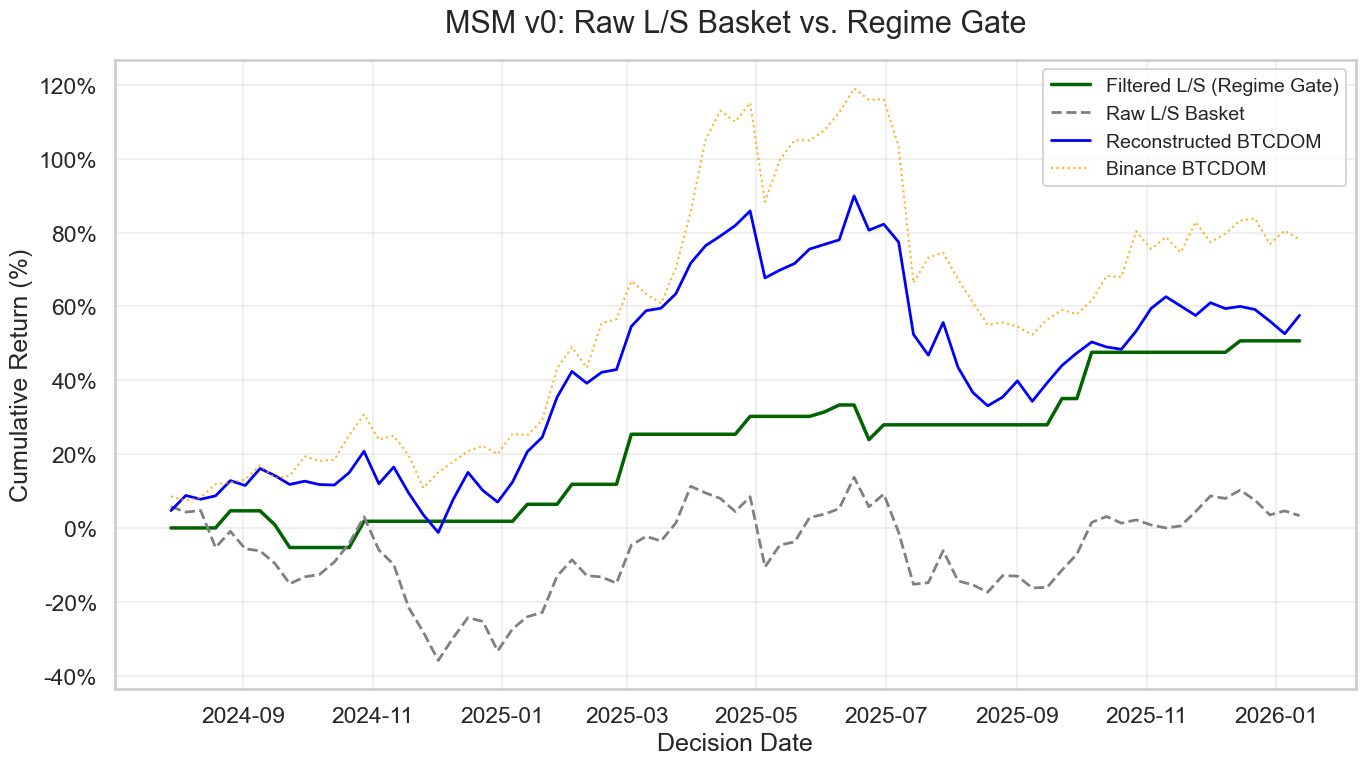

Saved: C:\Users\Admin\Documents\Cursor\notebooks\equity_curve_comparison.png


In [3]:
# Equity curve: 4 core series with gate ON shading
sns.set_context("talk")
fig, ax = plt.subplots(figsize=(14, 8))

# Background shading: light green when Gate is ON (strategy in the market)
for i in range(len(df)):
    if df["is_mrf_active"].iloc[i]:
        ax.axvspan(df["decision_date"].iloc[i], df["next_date"].iloc[i], color="green", alpha=0.12, zorder=0)
ax.set_facecolor("white")

# Core four series (avoid clutter) — plot as weekly steps
ax.plot(df["decision_date"], df["cum_raw_ls"] * 100, label="Raw L/S Basket", linewidth=2, color="gray", linestyle="--", drawstyle="steps-post", zorder=3)
ax.plot(df["decision_date"], df["cum_filtered_ls"] * 100, label="Gated L/S Basket", linewidth=2.5, color="darkgreen", linestyle="-", drawstyle="steps-post", zorder=4)
ax.plot(df["decision_date"], df["cum_recon_filtered"] * 100, label="Gated Reconstructed BTCDOM", linewidth=1.3, color="steelblue", linestyle="-.", alpha=0.9, drawstyle="steps-post", zorder=3)
ax.plot(df["decision_date"], df["cum_binance_filtered"] * 100, label="Gated Binance BTCDOM", linewidth=1.3, color="darkorange", linestyle="-.", alpha=0.9, drawstyle="steps-post", zorder=3)

ax.set_title("MSM v0: Raw vs Gated L/S + Gated Macro (shaded = Gate ON)", fontsize=22, pad=20)
ax.set_xlabel("Decision Date", fontsize=18)
ax.set_ylabel("Cumulative Return (%)", fontsize=18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0f}%"))
ax.legend(fontsize=11, loc="upper left", framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path_equity = BASE_DIR / "notebooks" / "equity_curve_comparison.png"
plt.savefig(path_equity, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {path_equity}")

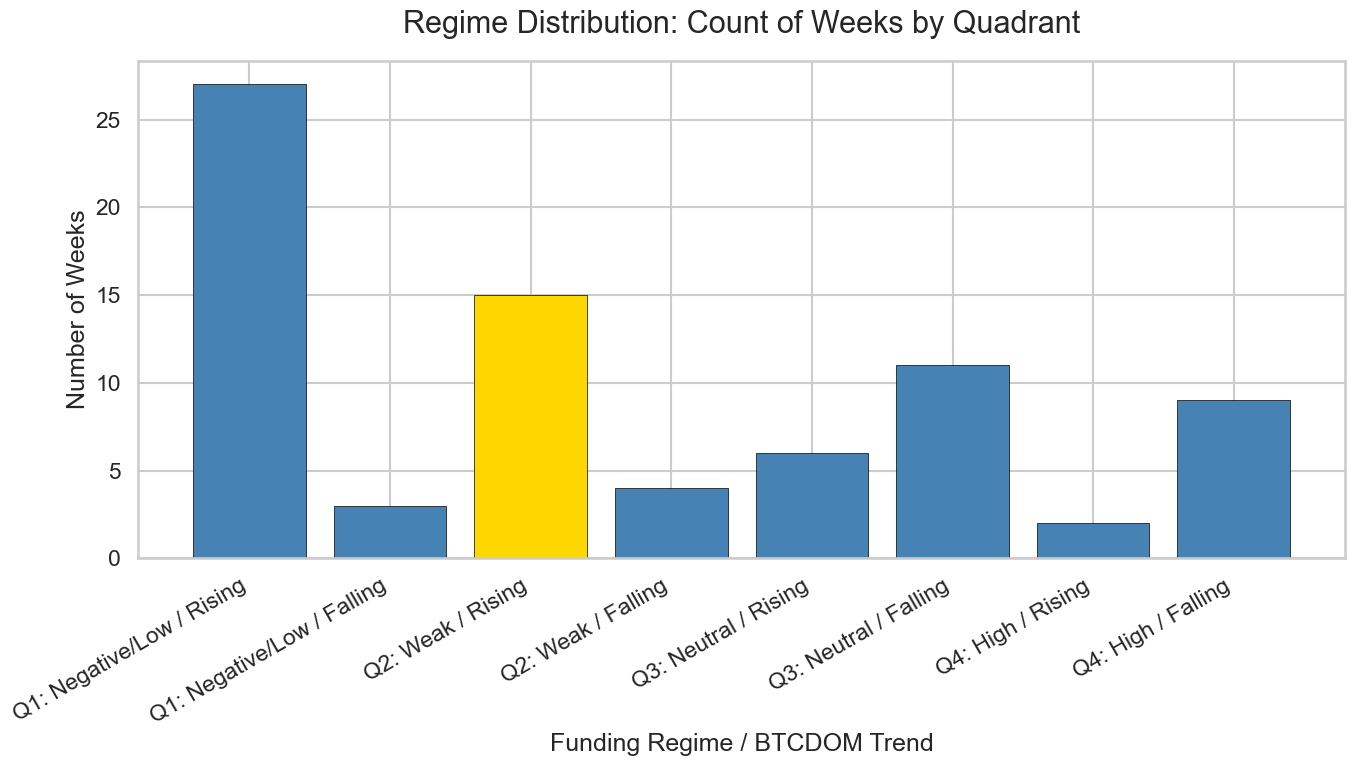

Saved: C:\Users\Admin\Documents\Cursor\notebooks\regime_distribution.png
     funding_regime BTCDOM_Trend  count                    quadrant  \
1  Q1: Negative/Low       Rising     27   Q1: Negative/Low / Rising   
0  Q1: Negative/Low      Falling      3  Q1: Negative/Low / Falling   
3          Q2: Weak       Rising     15           Q2: Weak / Rising   
2          Q2: Weak      Falling      4          Q2: Weak / Falling   
5       Q3: Neutral       Rising      6        Q3: Neutral / Rising   
4       Q3: Neutral      Falling     11       Q3: Neutral / Falling   
7          Q4: High       Rising      2           Q4: High / Rising   
6          Q4: High      Falling      9          Q4: High / Falling   

   is_disbelief  
1         False  
0         False  
3          True  
2         False  
5         False  
4         False  
7         False  
6         False  


In [4]:
# Task 2: Regime distribution (count of weeks per quadrant)
counts = df.groupby(["funding_regime", "BTCDOM_Trend"], observed=True).size().reset_index(name="count")
counts["quadrant"] = counts["funding_regime"].astype(str) + " / " + counts["BTCDOM_Trend"].astype(str)
counts["is_disbelief"] = (counts["funding_regime"] == "Q2: Weak") & (counts["BTCDOM_Trend"] == "Rising")
reg_order = ["Q1: Negative/Low", "Q2: Weak", "Q3: Neutral", "Q4: High"]
trend_order = ["Rising", "Falling"]
counts["_sort"] = counts["funding_regime"].astype(str).map({r: i for i, r in enumerate(reg_order)})
counts["_sort2"] = counts["BTCDOM_Trend"].astype(str).map({t: i for i, t in enumerate(trend_order)})
counts = counts.sort_values(["_sort", "_sort2"]).drop(columns=["_sort", "_sort2"])

sns.set_context("talk")
fig, ax = plt.subplots(figsize=(14, 8))
palette = ["gold" if q else "steelblue" for q in counts["is_disbelief"]]
bars = ax.bar(counts["quadrant"], counts["count"], color=palette, edgecolor="black", linewidth=0.5)
ax.set_title("Regime Distribution: Count of Weeks by Quadrant", fontsize=22, pad=20)
ax.set_ylabel("Number of Weeks", fontsize=18)
ax.set_xlabel("Funding Regime / BTCDOM Trend", fontsize=18)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
path_dist = BASE_DIR / "notebooks" / "regime_distribution.png"
plt.savefig(path_dist, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {path_dist}")
print(counts)

In [5]:
# Risk metrics: Annualized Sharpe (RF=0) and Max Drawdown
def annualized_sharpe(r: pd.Series, periods_per_year: int = 52) -> float:
    m, s = r.mean(), r.std()
    if s is None or s == 0 or np.isnan(s):
        return np.nan
    return (m / s) * np.sqrt(periods_per_year)

def max_drawdown_pct(r: pd.Series) -> float:
    wealth = (1 + r).cumprod()
    peaks = wealth.cummax()
    drawdowns = (wealth - peaks) / peaks
    return drawdowns.min() * 100  # as percentage

series_config = [
    (df["y"], "Raw L/S Basket"),
    (df["y_filtered"], "Gated L/S (Regime Gate)"),
    (df["ret_btcdom_recon"], "Reconstructed BTCDOM"),
    (df["recon_filtered"], "Gated Reconstructed BTCDOM"),
    (df["ret_btcdom_binance"], "Binance BTCDOM"),
    (df["binance_filtered"], "Gated Binance BTCDOM"),
]

rows = []
for ser, name in series_config:
    rows.append({
        "Strategy": name,
        "Annualized Sharpe": annualized_sharpe(ser),
        "Max Drawdown (%)": max_drawdown_pct(ser),
    })

risk_metrics = pd.DataFrame(rows)
print("\n=== Risk-Adjusted Performance ===\n")
print(risk_metrics.to_string(index=False))
risk_metrics


=== Risk-Adjusted Performance ===

                     Strategy  Annualized Sharpe  Max Drawdown (%)
               Raw L/S Basket           0.274754        -39.388565
   Filtered L/S (Regime Gate)           1.595087         -9.502146
         Reconstructed BTCDOM           1.162138        -29.936613
Filtered Reconstructed BTCDOM           1.684186         -4.888366
               Binance BTCDOM           1.344021        -30.464390
      Filtered Binance BTCDOM           1.836188         -2.984493


,Strategy,Annualized Sharpe,Max Drawdown (%)
0,Raw L/S Basket,0.274754,-39.388565
1,Filtered L/S (Regime Gate),1.595087,-9.502146
2,Reconstructed BTCDOM,1.162138,-29.936613
3,Filtered Reconstructed BTCDOM,1.684186,-4.888366
4,Binance BTCDOM,1.344021,-30.464390
5,Filtered Binance BTCDOM,1.836188,-2.984493


In [ ]:
# Diagnostic: Volatility Drag — compounded vs additive L/S return
import matplotlib.pyplot as plt

# Additive PnL for raw L/S basket (sum of weekly arithmetic spreads)
df["additive_raw_ls"] = df["y"].cumsum()

fig, ax = plt.subplots(figsize=(12, 7))
ax.step(df["decision_date"], df["cum_raw_ls"] * 100, where="post", label="Compounded Equity (cum_raw_ls)", linewidth=2.0, color="darkred")
ax.step(df["decision_date"], df["additive_raw_ls"] * 100, where="post", label="Additive PnL (sum y)", linewidth=2.0, color="navy")
ax.set_title("Diagnostic: Volatility Drag (Compounded vs Additive L/S Return)", fontsize=20, pad=18)
ax.set_xlabel("Decision Date", fontsize=16)
ax.set_ylabel("Return / PnL (%)", fontsize=16)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0f}%"))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc="best")
plt.tight_layout()
plt.show()

final_compounded = float(df["cum_raw_ls"].iloc[-1]) * 100.0
final_additive = float(df["additive_raw_ls"].iloc[-1]) * 100.0
print(f"Final compounded equity (cum_raw_ls): {final_compounded:.2f}%")
print(f"Final additive PnL (sum y): {final_additive:.2f}%")

In [ ]:
# Q3/Q4 diagnostic: Raw L/S basket risk metrics when funding regime is Q3 or Q4 only
q3_q4_mask = (df["funding_regime"] == "Q3: Neutral") | (df["funding_regime"] == "Q4: High")
y_q3_q4 = df.loc[q3_q4_mask, "y"]

def annualized_sharpe(r, periods_per_year=52):
    m, s = r.mean(), r.std()
    if s is None or s == 0 or np.isnan(s):
        return np.nan
    return (m / s) * np.sqrt(periods_per_year)

def max_drawdown_pct(r):
    wealth = (1 + r).cumprod()
    peaks = wealth.cummax()
    dd = (wealth - peaks) / peaks
    return dd.min() * 100

if len(y_q3_q4) > 0:
    sharpe_q3_q4 = annualized_sharpe(y_q3_q4)
    mdd_q3_q4 = max_drawdown_pct(y_q3_q4)
    print("=== Raw L/S Basket: Q3/Q4 Funding Regimes Only (Diagnostic for PM) ===")
    print(f"Weeks in Q3 or Q4: {len(y_q3_q4)}")
    print(f"Annualized Sharpe (RF=0, 52 periods/yr): {sharpe_q3_q4:.4f}")
    print(f"Max Drawdown (%): {mdd_q3_q4:.2f}%")
    print("(Q3/Q4 = high funding regimes; compare to Gated L/S Sharpe 1.60 and MDD -9.5% to show toxic drawdown in high-funding regimes.)")
else:
    print("No weeks with funding regime Q3 or Q4 in sample.")